# Micro-Project 3: Predicting Vulnerability Severity with Machine Learning Regression

**ANA500 -- Data Science Process**

- **Author:** Christian Cruz
- **Scope:** This notebook covers the full data science process, from **Acquire** through
**Act**, using machine learning regression (linear regression and support vector
regression) with scikit-learn. It builds on the same CVE dataset prepared in
Micro-Project 1 and explored visually in Micro-Project 2.

## Problem Statement
Security teams face a constantly growing volume of publicly disclosed vulnerabilities,
called Common Vulnerabilities and Exposures (CVEs), and must decide which to patch first.
Micro-Project 2 showed that disclosures have grown about twelve-fold since 2015 and that
most of them are serious. The official severity score (CVSS) is what teams usually sort
by, but it is calculated from a detailed technical analysis of each vulnerability, and
that analysis takes time. When a new CVE is published, a team often has to decide what to
look at first before that analysis is finished.

## Hypothesis Formulation
Basic descriptive facts about a CVE that are separate from its severity analysis,
specifically **who makes the affected product (vendor and product), what kind of weakness
it is (CWE type), when it was published, and how many products it affects**, carry enough
information to
estimate its CVSS severity score meaningfully better than guessing. If this is true, a
regression model trained on these facts should predict severity more accurately than a
baseline that always guesses the average score, on vulnerabilities it has never seen.

Micro-Project 2 already showed that the technical ingredients of the score (attack vector,
and the exploitability and impact sub-scores) line up with severity. That is expected,
because the score is calculated from them. This project deliberately asks the harder and
more useful question: **can severity be estimated without those ingredients?**

## Step 1: Acquire

**Data source:** [`fkie-cad/nvd-json-data-feeds`](https://github.com/fkie-cad/nvd-json-data-feeds),
a community-maintained reconstruction of NIST's National Vulnerability Database (NVD) bulk
JSON feeds, rebuilt from the official NVD API 2.0 and refreshed every two hours. This is
the same source and the same twelve-year window (2015 to 2026) used in Micro-Projects 1
and 2. Because the feed is live, record counts here are slightly higher than in earlier
micro-projects; the cleaning logic is unchanged.

Each yearly archive is downloaded only if it is not already present locally.

In [1]:
# ---- Standard library ----
import os
import lzma          # the yearly archives are .xz-compressed JSON
import json
import time
import urllib.request
from pathlib import Path

# ---- Data handling ----
import numpy as np
import pandas as pd

# ---- Charts (Matplotlib, same style system as Micro-Project 2) ----
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---- Machine learning (scikit-learn) ----
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility: one fixed "random seed" used everywhere randomness appears
# (the train/test split, sampling, cross-validation folds). Same value as the
# Module 3 class notebook, so every re-run produces identical results.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.autolayout"] = True
os.makedirs("figures", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Download the twelve yearly CVE archives (2015-2026), skipping any already on disk.
DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2015, 2027))
BASE_URL = "https://github.com/fkie-cad/nvd-json-data-feeds/releases/latest/download"

for year in YEARS:
    fname = f"CVE-{year}.json.xz"
    target = DATA_DIR / fname
    if target.exists():
        print(f"{fname}: already downloaded, skipping")
        continue
    print(f"{fname}: downloading ...")
    urllib.request.urlretrieve(f"{BASE_URL}/{fname}", target)

print("\nAll yearly CVE archives present in", DATA_DIR)

CVE-2015.json.xz: already downloaded, skipping
CVE-2016.json.xz: already downloaded, skipping
CVE-2017.json.xz: already downloaded, skipping
CVE-2018.json.xz: already downloaded, skipping
CVE-2019.json.xz: already downloaded, skipping
CVE-2020.json.xz: already downloaded, skipping
CVE-2021.json.xz: already downloaded, skipping
CVE-2022.json.xz: already downloaded, skipping
CVE-2023.json.xz: already downloaded, skipping
CVE-2024.json.xz: already downloaded, skipping
CVE-2025.json.xz: already downloaded, skipping
CVE-2026.json.xz: already downloaded, skipping

All yearly CVE archives present in data/raw


## Step 2: Prepare

### 2.1 Flatten the nested JSON (same extractor as Micro-Project 1)

Each CVE record is deeply nested, with each CVSS version's scoring stored in its own
sub-section. The function below is the same extractor written in Micro-Project 1. It turns
every record into one flat row, keeping each CVSS version in its **own** columns because
the versions are scored on different rubrics and are not interchangeable.

In [3]:
def first_metric(metric_list):
    """A CVE can carry several scores for the same CVSS version (e.g. one from NVD and
    one from the vendor). Prefer the one NVD marked 'Primary'; otherwise take the first."""
    if not metric_list:
        return None
    for m in metric_list:
        if m.get("type") == "Primary":
            return m
    return metric_list[0]


def extract_row(item):
    """Flatten one raw CVE record into a dictionary (one future table row)."""
    row = {
        "cve_id": item.get("id"),
        "published_date": item.get("published"),
        "vuln_status": item.get("vulnStatus"),
    }

    # English description text (kept in the dataset; NOT used as a model input)
    row["description_en"] = next(
        (d.get("value") for d in item.get("descriptions", []) if d.get("lang") == "en"), None)

    # Vendor / product: take the first listed, and count how many products are affected
    vendors, products = [], []
    for src in item.get("affected", []):
        for ad in src.get("affectedData", []):
            if ad.get("vendor"):
                vendors.append(ad["vendor"])
            if ad.get("product"):
                products.append(ad["product"])
    row["primary_vendor"] = vendors[0] if vendors else None
    row["primary_product"] = products[0] if products else None
    row["num_affected_products"] = len(products)

    # Weakness type (CWE), e.g. CWE-79 = cross-site scripting
    row["cwe_id"] = None
    weaknesses = item.get("weaknesses", [])
    if weaknesses:
        row["cwe_id"] = next((d.get("value") for d in weaknesses[0].get("description", [])
                              if d.get("lang") == "en"), None)

    metrics = item.get("metrics", {})

    # CVSS v2 (oldest standard): only the score is needed here
    v2 = first_metric(metrics.get("cvssMetricV2"))
    row["v2_score"] = v2["cvssData"].get("baseScore") if v2 else None

    # CVSS v3.x (v3.1 preferred over v3.0): the score is our prediction TARGET.
    # The attack vector and the two sub-scores are pulled out only to demonstrate
    # leakage in section 2.4; they are never used as model inputs.
    v3 = first_metric(metrics.get("cvssMetricV31")) or first_metric(metrics.get("cvssMetricV30"))
    row["v3_version"] = row["v3_score"] = row["v3_attack_vector"] = None
    row["v3_exploitability_score"] = row["v3_impact_score"] = None
    if v3:
        cd = v3.get("cvssData", {})
        row["v3_version"] = cd.get("version")
        row["v3_score"] = cd.get("baseScore")
        row["v3_attack_vector"] = cd.get("attackVector")
        row["v3_exploitability_score"] = v3.get("exploitabilityScore")
        row["v3_impact_score"] = v3.get("impactScore")

    # CVSS v4.0 (newest standard): only the score is needed here
    v4 = first_metric(metrics.get("cvssMetricV40"))
    row["v4_score"] = v4["cvssData"].get("baseScore") if v4 else None
    return row


# Parse every yearly archive into one list of rows, then one DataFrame.
records = []
for year in YEARS:
    with lzma.open(DATA_DIR / f"CVE-{year}.json.xz") as f:
        data = json.load(f)
    records.extend(extract_row(item) for item in data["cve_items"])
    print(f"CVE-{year}: {len(data['cve_items']):,} records")

df_raw = pd.DataFrame.from_records(records)
print(f"\nTotal records flattened: {len(df_raw):,}")

CVE-2015: 8,780 records


CVE-2016: 10,648 records


CVE-2017: 17,106 records


CVE-2018: 17,817 records


CVE-2019: 17,624 records


...

CVE-2023: 31,448 records


CVE-2024: 39,256 records


CVE-2025: 45,324 records


CVE-2026: 66,726 records



Total records flattened: 326,831


### 2.2 Clean the main dataset

The same cleaning rules as Micro-Project 1, with one change:

1. **Fix the "n/a" placeholder.** Some records contain the literal text `"n/a"` in the
   vendor or product field instead of a true blank. These are converted to real missing
   values so they are not mistaken for a vendor called "n/a".
2. **Drop withdrawn (`Rejected`) CVE IDs.** These are not real vulnerabilities.
3. **Keep unscored records in the main dataset.** In Micro-Project 1, CVEs with no CVSS
   score yet were removed at this stage. They are real vulnerabilities still waiting for
   analysis, so they now stay in the main cleaned dataset and are only set aside in
   section 2.3, where the modeling subset is built.
4. **Parse dates** and derive the publication year.

In [4]:
df = df_raw.copy()

# 1. Placeholder text -> real missing value
for col in ["primary_vendor", "primary_product"]:
    is_placeholder = df[col].astype(str).str.strip().str.lower().isin(["", "n/a", "none", "nan"])
    df.loc[is_placeholder, col] = np.nan

# 2. Drop withdrawn CVE IDs
n_rejected = (df["vuln_status"] == "Rejected").sum()
df = df[df["vuln_status"] != "Rejected"].copy()

# 4. Dates
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
df["published_year"] = df["published_date"].dt.year

# A record is "scored" if it has a CVSS score under ANY version
df["has_any_score"] = df[["v2_score", "v3_score", "v4_score"]].notna().any(axis=1)

print(f"Raw records:                    {len(df_raw):,}")
print(f"Dropped as Rejected (withdrawn): {n_rejected:,}")
print(f"Main cleaned dataset:           {len(df):,} records")
print(f"  ...of which still unscored:   {(~df['has_any_score']).sum():,} (kept)")
print("\nVendor missing:  {:.1%}".format(df["primary_vendor"].isna().mean()))
print("Product missing: {:.1%}".format(df["primary_product"].isna().mean()))

# 3. Save the main cleaned dataset, unscored records included.
df.to_pickle("data/cve_clean_mp3.pkl")

Raw records:                    326,831
Dropped as Rejected (withdrawn): 15,429
Main cleaned dataset:           311,402 records
  ...of which still unscored:   3,256 (kept)

Vendor missing:  29.5%
Product missing: 24.2%


### 2.3 Build the modeling subset: CVSS v3.x scores only

A regression model needs one consistent target to predict. CVSS v2, v3.x, and v4.0 all
produce a number from 0 to 10, but they calculate it with different rubrics, so a 7.0
under one version does not mean the same thing as a 7.0 under another. Mixing them would
ask the model to hit a target whose meaning changes from row to row.

The modeling subset therefore keeps only records that have a **CVSS v3.0 or v3.1** score.
These two versions share the same scale and severity bands. Many recent CVEs list v4.0 as
their newest score but *also* carry a v3.1 score; those records are included, using their
v3.x score.

Records are left out of the modeling subset (but stay in the main dataset) if they:
- have **no score at all yet** (nothing for a model to learn from), or
- were scored **only under v2 or only under v4.0** (a different rubric).

In [5]:
has_v3 = df["v3_score"].notna()
unscored = ~df["has_any_score"]
other_version_only = df["has_any_score"] & ~has_v3

summary = pd.DataFrame({
    "Records": [len(df), unscored.sum(), other_version_only.sum(), has_v3.sum()],
}, index=["Main cleaned dataset",
          "  minus: no score yet",
          "  minus: scored only under v2 or v4.0",
          "= Modeling subset (CVSS v3.x)"])
print(summary.to_string(formatters={"Records": "{:,}".format}))

model_df = df[has_v3].copy()
model_df["v3_score"] = model_df["v3_score"].astype(float)
print("\nv3 version mix in modeling subset:")
print(model_df["v3_version"].value_counts().to_string())

                                      Records
Main cleaned dataset                  311,402
  minus: no score yet                   3,256
  minus: scored only under v2 or v4.0  12,080
= Modeling subset (CVSS v3.x)         296,066

v3 version mix in modeling subset:
v3_version
3.1    253742
3.0     42324


### 2.4 Choosing the inputs, and avoiding leakage

**Leakage** happens when a model is given information that already contains the answer.
The CVSS v3 score is calculated by a fixed formula from a handful of ingredients, chiefly
the attack vector and the exploitability and impact sub-scores. If those were used as
inputs, the model would simply be re-learning the official formula. It would look nearly
perfect and teach us nothing about estimating severity *before* that analysis is done.

The cell below demonstrates this, using the two sub-scores alone:

In [6]:
# Demonstration only: a linear regression given the score's own ingredients.
leak_X = model_df[["v3_exploitability_score", "v3_impact_score"]].astype(float)
leak_r2 = LinearRegression().fit(leak_X, model_df["v3_score"]).score(leak_X, model_df["v3_score"])
print(f"R-squared using the score's own sub-scores: {leak_r2:.3f}")
print("This near-perfect fit is the formula being reverse-engineered, not real prediction,")
print("so these columns (and attack vector) are excluded from every model below.")

R-squared using the score's own sub-scores: 0.986
This near-perfect fit is the formula being reverse-engineered, not real prediction,
so these columns (and attack vector) are excluded from every model below.


**Inputs used instead** (descriptive facts about the CVE, none of them part of the score
formula):

| Input | Type | What it captures |
|---|---|---|
| `primary_vendor` | category | Who makes the affected product |
| `primary_product` | category | Which product is affected |
| `cwe_id` | category | The kind of weakness (e.g. cross-site scripting, buffer overflow) |
| `published_year` | number | When it was disclosed |
| `num_affected_products` | number | How widely the vulnerability reaches |

Missing vendor, product, or CWE values are filled with the label `"Unknown"` rather than
dropped. "We don't know the vendor yet" is itself a realistic condition for a new CVE.

In [7]:
CAT_FEATURES = ["primary_vendor", "primary_product", "cwe_id"]
NUM_FEATURES = ["published_year", "num_affected_products"]
TARGET = "v3_score"

for col in CAT_FEATURES:
    model_df[col] = model_df[col].fillna("Unknown")

# How many distinct values does each category have? This matters for encoding (3.2).
for col in CAT_FEATURES:
    print(f"{col:18s} {model_df[col].nunique():>7,} distinct values")

primary_vendor      23,982 distinct values
primary_product     53,998 distinct values
cwe_id                 765 distinct values


### 2.5 Quick look at the target and the numeric inputs

Same idea as the minimal, targeted EDA in the Module 3 class notebook: check the shape of
what we are predicting, and whether any numeric input is badly skewed.

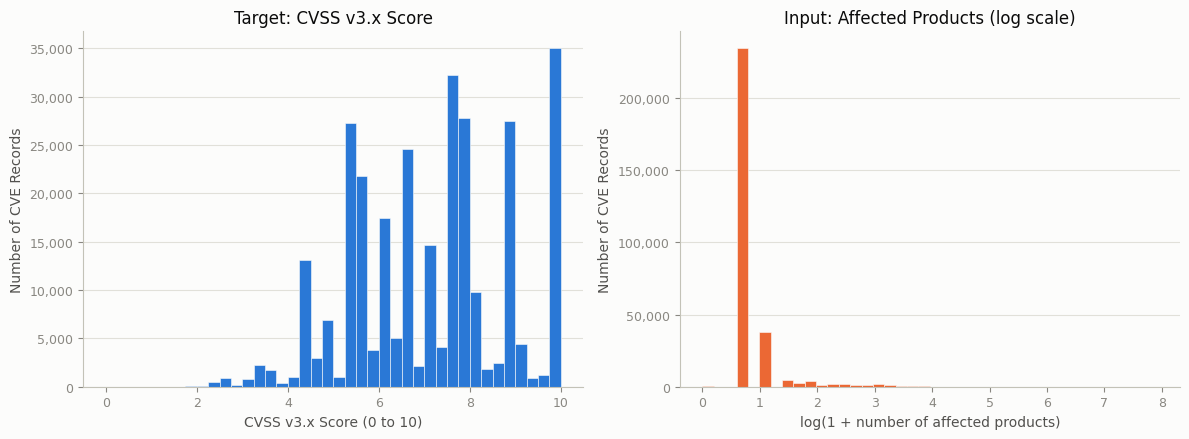

count    296066.00
mean          7.07
std           1.69
min           0.00
25%           5.50
50%           7.20
75%           8.20
max          10.00

num_affected_products: median 1, max 2,749


In [8]:
# Shared chart style from Micro-Project 2, so every figure in the portfolio matches.
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
STATUS = {"LOW": "#0ca30c", "MEDIUM": "#fab219", "HIGH": "#ec835a", "CRITICAL": "#d03b3b"}
SEVERITY_ORDER = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
SURFACE, INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRIDLINE, AXIS_LINE = "#e1e0d9", "#c3c2b7"


def style_ax(ax, y_grid=True, x_grid=False):
    """Apply the shared look (background, spines, grid, tick colors) to an axis."""
    ax.set_facecolor(SURFACE)
    ax.figure.set_facecolor(SURFACE)
    for name, spine in ax.spines.items():
        if name in ("top", "right"):
            spine.set_visible(False)
        else:
            spine.set_color(AXIS_LINE)
            spine.set_linewidth(0.8)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.xaxis.label.set_color(INK_SECONDARY)
    ax.yaxis.label.set_color(INK_SECONDARY)
    ax.title.set_color(INK_PRIMARY)
    if y_grid:
        ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    if x_grid:
        ax.grid(axis="x", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax


def thousands(ax, axis="y"):
    """Comma-format tick labels, e.g. 10,000 instead of 10000."""
    fmt = mticker.FuncFormatter(lambda v, p: f"{int(v):,}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def severity_band(score):
    """CVSS v3 qualitative bands. 0.0 ('None') is grouped with LOW for simplicity."""
    return pd.cut(score, bins=[-0.1, 3.95, 6.95, 8.95, 10.0], labels=SEVERITY_ORDER)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(model_df[TARGET], bins=np.arange(0, 10.25, 0.25), color=CAT[0],
             edgecolor=SURFACE, linewidth=0.4)
axes[0].set_title("Target: CVSS v3.x Score")
axes[0].set_xlabel("CVSS v3.x Score (0 to 10)")
axes[0].set_ylabel("Number of CVE Records")
style_ax(axes[0]); thousands(axes[0])

axes[1].hist(np.log1p(model_df["num_affected_products"]), bins=40, color=CAT[1],
             edgecolor=SURFACE, linewidth=0.4)
axes[1].set_title("Input: Affected Products (log scale)")
axes[1].set_xlabel("log(1 + number of affected products)")
axes[1].set_ylabel("Number of CVE Records")
style_ax(axes[1]); thousands(axes[1])
plt.show()

print(model_df[TARGET].describe().round(2).to_string())
print("\nnum_affected_products: median {:.0f}, max {:,}".format(
    model_df["num_affected_products"].median(), model_df["num_affected_products"].max()))

**Reading these charts:** The target is lumpy rather than smooth. CVSS scores come from a
formula with a limited set of possible outcomes, so certain values (such as 5.4, 6.1, 7.5,
7.8, and 9.8) are very common. Most scores sit between 5 and 9. The number of affected
products is extremely right-skewed (most CVEs affect one product, a few affect thousands),
so it is log-transformed before modeling. Without that, a handful of extreme values would
dominate the scaling step.

## Step 3: Analyze Data

### 3.1 Train/test split (75/25)

The data is split once into a **training set (75%)** that the models learn from and a
**test set (25%)** that is locked away until the very end. The test set acts as a final
exam on CVEs the models have never seen. This is the main protection against
**overfitting** (memorizing the training data instead of learning the real pattern). If a
model scores much better on training data than on test data, that gap is overfitting.

Same settings as the class notebook: `test_size=0.25`, `random_state=42`. The class
notebook also used `stratify=y`, which keeps class proportions equal in both sets. That
option applies to categories, not to a continuous number like a CVSS score. With roughly
300,000 records, a plain random split already gives both sets the same score distribution
(checked below).

The exact split is saved by CVE ID so the same training and test sets can be
reproduced later.

In [9]:
X = model_df[CAT_FEATURES + NUM_FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print(f"Training set: {len(X_train):,} records")
print(f"Test set:     {len(X_test):,} records")

# Did the random split keep the score distribution the same in both sets?
check = pd.DataFrame({
    "train": severity_band(y_train).value_counts(normalize=True).reindex(SEVERITY_ORDER),
    "test":  severity_band(y_test).value_counts(normalize=True).reindex(SEVERITY_ORDER),
}).mul(100).round(1)
print("\nShare of each severity band (%):")
print(check.to_string())

# Save the split by CVE ID so the exact same train/test sets can be reproduced later.
split_ids = pd.concat([
    pd.DataFrame({"cve_id": model_df.loc[X_train.index, "cve_id"], "split": "train"}),
    pd.DataFrame({"cve_id": model_df.loc[X_test.index, "cve_id"], "split": "test"}),
])
split_ids.to_csv("data/mp3_train_test_split.csv", index=False)
print("\nSaved data/mp3_train_test_split.csv")

Training set: 222,049 records
Test set:     74,017 records

Share of each severity band (%):
          train  test
v3_score             
LOW         2.3   2.3
MEDIUM     43.0  43.0
HIGH       40.7  40.6
CRITICAL   14.0  14.1



Saved data/mp3_train_test_split.csv


### 3.2 Turning inputs into numbers (preprocessing pipeline)

Models only read numbers, so each input is converted inside a scikit-learn **Pipeline**,
the same pattern used in the class notebook (`scaler -> model`). Putting the
preprocessing inside the pipeline means it is learned from the training data only and then
applied unchanged to the test data, which avoids accidentally peeking at the test set.

- **Categories (vendor, product, CWE)** use *one-hot encoding*: one yes/no column per
  value. There are tens of thousands of distinct vendors and products, so any value that
  appears fewer than 50 times in the training data is grouped into a shared "infrequent"
  column. Values never seen during training are also mapped there.
- **Numbers (year, affected products)** are log-transformed where skewed and then
  **standardized** (StandardScaler). As the class notebook notes, SVMs are sensitive to
  feature scale, so we always scale first.

In [10]:
def make_preprocessor():
    """Build a fresh, unfitted preprocessing step (each model gets its own copy)."""
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50),
         CAT_FEATURES),
        ("num", Pipeline([
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),   # tames the skewed product count
            ("scaler", StandardScaler()),
        ]), NUM_FEATURES),
    ])

n_cols = make_preprocessor().fit(X_train).transform(X_train.iloc[:1]).shape[1]
print(f"After encoding, each CVE is described by {n_cols:,} numeric columns.")

After encoding, each CVE is described by 727 numeric columns.


### 3.3 How the models are graded

Regression predicts a number, so it is graded by **how far off** the predictions are,
rather than with the confusion matrix used for classification:

- **MAE (mean absolute error):** on average, how many CVSS points the prediction misses
  by. Easiest to read: an MAE of 1.0 means "typically off by about one point".
- **RMSE (root mean squared error):** like MAE, but big misses count extra. Useful for
  spotting a model that is usually close but occasionally far off.
- **R-squared:** how much of the variation in scores the model explains. **0 means no
  better than always guessing the average; 1 means perfect.**

Every model is compared against a **baseline** that ignores all inputs and always guesses
the average training score. A model is only useful if it clearly beats this baseline.
Each model is also graded on its own training data, so any overfitting shows up as a gap
between training and test results.

In [11]:
results = []   # one row per model, collected for the comparison table


def evaluate(name, model, X_tr, y_tr, train_rows):
    """Score a fitted model on the training data and on the held-out test set."""
    t0 = time.time()
    pred_test = model.predict(X_test)
    pred_train = model.predict(X_tr)
    row = {
        "Model": name,
        "Trained on": f"{train_rows:,} rows",
        "Test MAE": mean_absolute_error(y_test, pred_test),
        "Test RMSE": mean_squared_error(y_test, pred_test) ** 0.5,
        "Test R2": r2_score(y_test, pred_test),
        "Train R2": r2_score(y_tr, pred_train),
    }
    row["Overfit gap (Train R2 - Test R2)"] = row["Train R2"] - row["Test R2"]
    results.append(row)
    print(f"{name}: test MAE {row['Test MAE']:.3f} | test RMSE {row['Test RMSE']:.3f} | "
          f"test R2 {row['Test R2']:.3f} | train R2 {row['Train R2']:.3f} "
          f"({time.time() - t0:.0f}s to predict)")
    return pred_test


# Baseline: always guess the average training score.
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
pred_baseline = evaluate("Baseline (always guess the average)", baseline,
                         X_train, y_train, len(X_train))
print(f"\nThe baseline always predicts {y_train.mean():.2f}.")

Baseline (always guess the average): test MAE 1.423 | test RMSE 1.698 | test R2 -0.000 | train R2 0.000 (0s to predict)

The baseline always predicts 7.07.


### 3.4 Linear regression

**Intuition:** linear regression finds the single straight-line relationship (a weighted
sum of the inputs) that keeps predictions as close as possible to the real scores. Each
one-hot column gets its own weight, so the model effectively learns "CVEs of this weakness
type, from this vendor, tend to score about this many points higher or lower".

In [12]:
linreg = Pipeline([
    ("prep", make_preprocessor()),
    ("model", LinearRegression()),
])
t0 = time.time()
linreg.fit(X_train, y_train)
print(f"Trained in {time.time() - t0:.0f}s")
pred_linreg = evaluate("Linear Regression", linreg, X_train, y_train, len(X_train))

Trained in 2s


Linear Regression: test MAE 1.099 | test RMSE 1.410 | test R2 0.310 | train R2 0.315 (1s to predict)


#### 3.4.1 Cross-validation and regularization tuning

Following section 4.1 of the class notebook, the linear model is tuned with
**cross-validation** (`GridSearchCV`, 5 folds). For linear regression, the regularized
version is called **Ridge regression**. Its `alpha` setting adds a penalty on large
weights to discourage overfitting. A larger alpha means a stronger penalty and a simpler
model. (It is the mirror image of `C` in logistic regression and SVM, where a *smaller*
value means stronger regularization.)

In [13]:
ridge_pipe = Pipeline([
    ("prep", make_preprocessor()),
    ("model", Ridge()),
])
param_grid_ridge = {"model__alpha": [0.1, 1, 10, 100]}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time()
grid_ridge = GridSearchCV(ridge_pipe, param_grid_ridge,
                          scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
grid_ridge.fit(X_train, y_train)
print(f"Grid search finished in {time.time() - t0:.0f}s")
print("Best alpha:", grid_ridge.best_params_["model__alpha"])
print(f"Best cross-validated MAE: {-grid_ridge.best_score_:.3f}")

best_ridge = grid_ridge.best_estimator_
pred_ridge = evaluate("Ridge Regression (tuned)", best_ridge, X_train, y_train, len(X_train))

Grid search finished in 13s
Best alpha: 0.1
Best cross-validated MAE: 1.100


Ridge Regression (tuned): test MAE 1.099 | test RMSE 1.410 | test R2 0.310 | train R2 0.315 (0s to predict)


### 3.5 Support Vector Regression (SVR)

**Intuition:** SVR is the regression version of the SVM from the class notebook. Instead of
drawing a boundary *between* two groups with the widest possible gap, it fits a line or
curve with a tolerance band (width set by `epsilon`) around it. Predictions that land
inside the band count as "close enough" and are not penalized, and only points outside the
band push the fit. With the **RBF kernel** (the same kernel trick from the class notebook),
the fitted curve can bend to follow non-linear patterns that a straight line would miss.

Key settings, as in the class notebook:
- `C`: regularization (how hard the model chases points outside the band).
- `gamma`: how far a single training example's influence reaches.
- `epsilon`: width of the "close enough" band, in CVSS points.

**A practical constraint.** RBF SVR's training time grows roughly with the *square* of the
number of rows, so training it on all ~222,000 training records is not practical. The
standard approach is used instead:
1. tune the settings with 5-fold cross-validation on a random sample of 8,000 training
   records, then
2. train the final SVR on a larger random sample of 30,000 training records.

It is still graded on the **full** test set. For a fair comparison, a plain linear
regression is also trained on the *same* 30,000-record sample.

In [14]:
# Step 1: tune C, gamma and epsilon on a small random sample with 5-fold CV.
tune_idx = X_train.sample(8_000, random_state=RANDOM_STATE).index
svr_pipe = Pipeline([
    ("prep", make_preprocessor()),
    ("model", SVR(kernel="rbf", cache_size=1000)),
])
param_grid_svr = {
    "model__C": [1, 10],
    "model__gamma": ["scale", 0.01],
    "model__epsilon": [0.25, 0.5],
}
t0 = time.time()
grid_svr = GridSearchCV(svr_pipe, param_grid_svr,
                        scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
grid_svr.fit(X_train.loc[tune_idx], y_train.loc[tune_idx])
print(f"Grid search finished in {time.time() - t0:.0f}s")
print("Best SVR settings:", grid_svr.best_params_)
print(f"Best cross-validated MAE (on the 8,000-row sample): {-grid_svr.best_score_:.3f}")

# Show every combination tried, best first, so the tuning is transparent.
cv_table = pd.DataFrame(grid_svr.cv_results_)[
    ["param_model__C", "param_model__gamma", "param_model__epsilon", "mean_test_score"]]
cv_table["CV MAE"] = -cv_table.pop("mean_test_score")
print(cv_table.sort_values("CV MAE").round(3).to_string(index=False))

Grid search finished in 36s
Best SVR settings: {'model__C': 1, 'model__epsilon': 0.25, 'model__gamma': 'scale'}
Best cross-validated MAE (on the 8,000-row sample): 1.104
 param_model__C param_model__gamma  param_model__epsilon  CV MAE
              1              scale                  0.25   1.104
             10              scale                  0.25   1.117
              1              scale                  0.50   1.122
             10               0.01                  0.25   1.128
             10              scale                  0.50   1.132
             10               0.01                  0.50   1.149
              1               0.01                  0.25   1.170
              1               0.01                  0.50   1.175


In [15]:
# Step 2: train the final SVR, with the best settings, on a 30,000-row random sample.
SVR_SAMPLE = 30_000
svr_idx = X_train.sample(SVR_SAMPLE, random_state=RANDOM_STATE).index
X_svr, y_svr = X_train.loc[svr_idx], y_train.loc[svr_idx]

best_svr = Pipeline([
    ("prep", make_preprocessor()),
    ("model", SVR(kernel="rbf", cache_size=2000,
                  C=grid_svr.best_params_["model__C"],
                  gamma=grid_svr.best_params_["model__gamma"],
                  epsilon=grid_svr.best_params_["model__epsilon"])),
])
t0 = time.time()
best_svr.fit(X_svr, y_svr)
print(f"SVR trained on {SVR_SAMPLE:,} rows in {time.time() - t0:.0f}s")
pred_svr = evaluate("SVR, RBF kernel (tuned)", best_svr, X_svr, y_svr, SVR_SAMPLE)

# Fair comparison: linear regression trained on exactly the same 30,000 rows.
linreg_same = Pipeline([("prep", make_preprocessor()), ("model", LinearRegression())])
linreg_same.fit(X_svr, y_svr)
pred_linreg_same = evaluate("Linear Regression (same 30k sample as SVR)", linreg_same,
                            X_svr, y_svr, SVR_SAMPLE)

SVR trained on 30,000 rows in 41s


SVR, RBF kernel (tuned): test MAE 1.058 | test RMSE 1.415 | test R2 0.306 | train R2 0.348 (97s to predict)


Linear Regression (same 30k sample as SVR): test MAE 1.129 | test RMSE 1.441 | test R2 0.279 | train R2 0.283 (0s to predict)


### 3.6 Model comparison

In [16]:
results_df = pd.DataFrame(results).set_index("Model")
pd.set_option("display.width", 200)
print(results_df.round(3).to_string())

baseline_mae = results_df.loc["Baseline (always guess the average)", "Test MAE"]
for name in ["Linear Regression", "Ridge Regression (tuned)", "SVR, RBF kernel (tuned)"]:
    mae = results_df.loc[name, "Test MAE"]
    print(f"{name}: {(1 - mae / baseline_mae):.0%} smaller average error than the baseline")

results_df.round(4).to_csv("figures/mp3_results.csv")

                                              Trained on  Test MAE  Test RMSE  Test R2  Train R2  Overfit gap (Train R2 - Test R2)
Model                                                                                                                             
Baseline (always guess the average)         222,049 rows     1.423      1.698   -0.000     0.000                             0.000
Linear Regression                           222,049 rows     1.099      1.410    0.310     0.315                             0.005
Ridge Regression (tuned)                    222,049 rows     1.099      1.410    0.310     0.315                             0.005
SVR, RBF kernel (tuned)                      30,000 rows     1.058      1.415    0.306     0.348                             0.042
Linear Regression (same 30k sample as SVR)   30,000 rows     1.129      1.441    0.279     0.283                             0.004
Linear Regression: 23% smaller average error than the baseline
Ridge Regression (tu

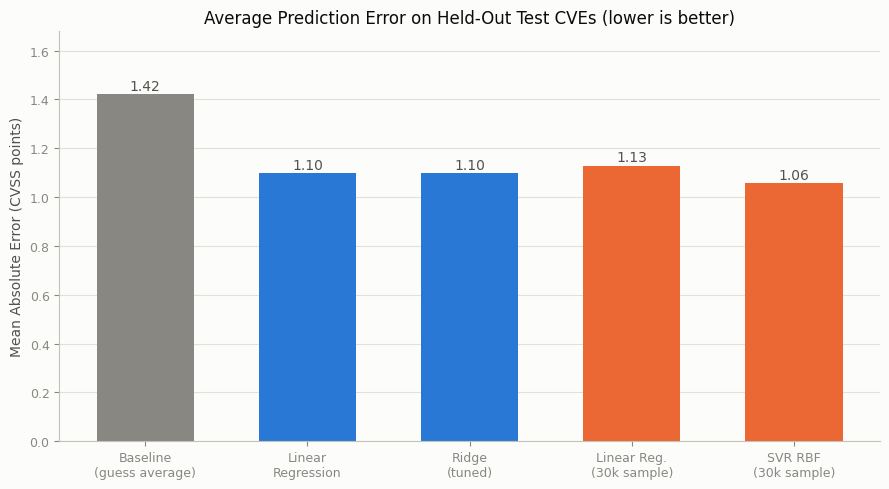

In [17]:
# Bar chart: average error (MAE) on the held-out test set, lower is better.
show = ["Baseline (always guess the average)", "Linear Regression",
        "Ridge Regression (tuned)", "Linear Regression (same 30k sample as SVR)",
        "SVR, RBF kernel (tuned)"]
labels = ["Baseline\n(guess average)", "Linear\nRegression", "Ridge\n(tuned)",
          "Linear Reg.\n(30k sample)", "SVR RBF\n(30k sample)"]
colors = [INK_MUTED, CAT[0], CAT[0], CAT[1], CAT[1]]
vals = results_df.loc[show, "Test MAE"].values

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, vals, color=colors, width=0.6)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=10, color=INK_SECONDARY)
ax.set_title("Average Prediction Error on Held-Out Test CVEs (lower is better)")
ax.set_ylabel("Mean Absolute Error (CVSS points)")
ax.set_ylim(0, max(vals) * 1.18)
style_ax(ax)
fig.savefig("figures/mae_comparison.png", dpi=200, facecolor=SURFACE)
plt.show()

### 3.7 Predicted vs. actual scores

A perfect model would put every point on the diagonal line. With hundreds of thousands of
overlapping points, a *hexbin* chart (darker = more CVEs) shows where predictions actually
concentrate.

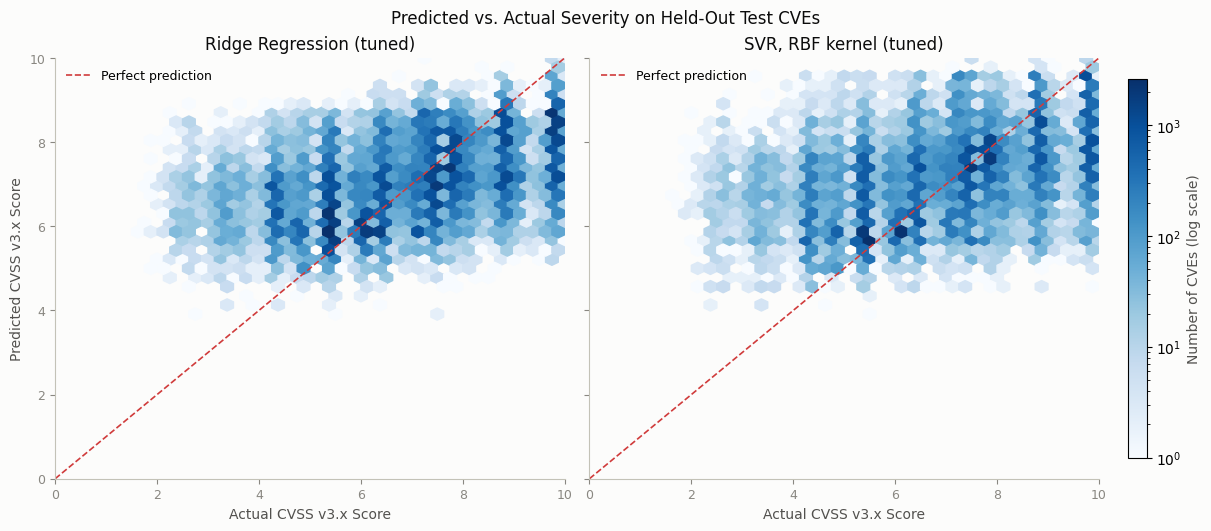

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, layout="constrained")
for ax, pred, title in [(axes[0], pred_ridge, "Ridge Regression (tuned)"),
                        (axes[1], pred_svr, "SVR, RBF kernel (tuned)")]:
    hb = ax.hexbin(y_test, pred, gridsize=40, cmap="Blues", mincnt=1, bins="log",
                   extent=(0, 10, 0, 10))
    ax.plot([0, 10], [0, 10], color=STATUS["CRITICAL"], linewidth=1.2, linestyle="--",
            label="Perfect prediction")
    ax.set_title(title)
    ax.set_xlabel("Actual CVSS v3.x Score")
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    style_ax(ax, y_grid=False)
    ax.legend(frameon=False, loc="upper left", fontsize=9)
axes[0].set_ylabel("Predicted CVSS v3.x Score")
cb = fig.colorbar(hb, ax=axes, shrink=0.9, pad=0.02)
cb.set_label("Number of CVEs (log scale)", color=INK_SECONDARY)
fig.suptitle("Predicted vs. Actual Severity on Held-Out Test CVEs", color=INK_PRIMARY)
fig.savefig("figures/pred_vs_actual.png", dpi=200, facecolor=SURFACE, bbox_inches="tight")
plt.show()

### 3.8 Where the errors happen: error by severity band

Average signed error by actual severity band (CVSS points):
          Ridge   SVR
band                 
LOW        3.32  3.42
MEDIUM     0.90  0.91
HIGH      -0.50 -0.37
CRITICAL  -1.82 -1.69

Ridge MAE by band:
band
LOW         3.32
MEDIUM      1.04
HIGH        0.78
CRITICAL    1.82


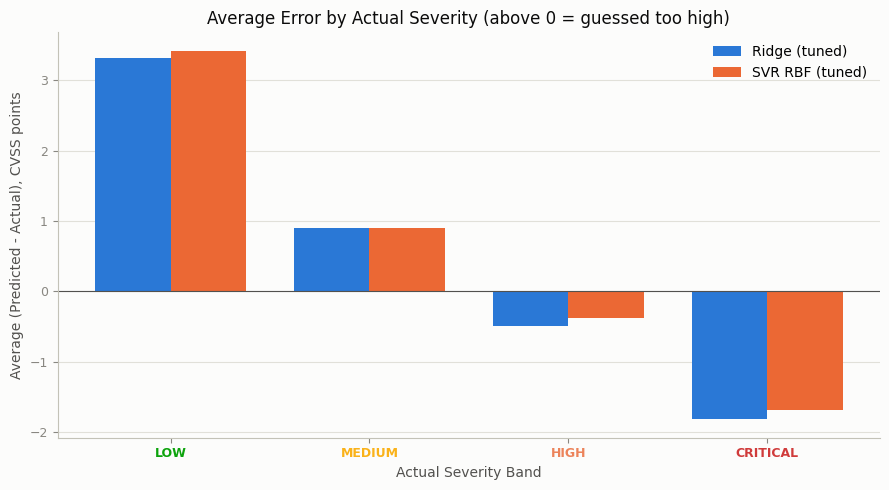

In [19]:
# Signed error = predicted - actual. Positive means the model guessed too HIGH,
# negative means it guessed too LOW. Averaged within each actual severity band.
band = severity_band(y_test)
err = pd.DataFrame({
    "Ridge": pred_ridge - y_test,
    "SVR": pred_svr - y_test,
    "band": band,
}).groupby("band", observed=True)[["Ridge", "SVR"]].mean().reindex(SEVERITY_ORDER)
abs_err = pd.DataFrame({"Ridge": np.abs(pred_ridge - y_test), "band": band}) \
    .groupby("band", observed=True)["Ridge"].mean().reindex(SEVERITY_ORDER)
print("Average signed error by actual severity band (CVSS points):")
print(err.round(2).to_string())
print("\nRidge MAE by band:")
print(abs_err.round(2).to_string())

x = np.arange(len(SEVERITY_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w / 2, err["Ridge"], w, color=CAT[0], label="Ridge (tuned)")
ax.bar(x + w / 2, err["SVR"], w, color=CAT[1], label="SVR RBF (tuned)")
ax.axhline(0, color=INK_SECONDARY, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(SEVERITY_ORDER)
ax.set_title("Average Error by Actual Severity (above 0 = guessed too high)")
ax.set_xlabel("Actual Severity Band")
ax.set_ylabel("Average (Predicted - Actual), CVSS points")
style_ax(ax)
for t, sev in zip(ax.get_xticklabels(), SEVERITY_ORDER):
    t.set_color(STATUS[sev]); t.set_fontweight("bold")
ax.legend(frameon=False)
fig.savefig("figures/error_by_band.png", dpi=200, facecolor=SURFACE)
plt.show()

### 3.9 What drives the predictions: weakness type

The tuned Ridge model has the same accuracy as plain linear regression (section 3.6) but
more stable weights, so its weights are used to see which inputs push a predicted score up
or down. Each weight is in CVSS points, relative to an otherwise identical CVE.

The chart focuses on **weakness type (CWE)**, limited to the 40 types with at least 1,000
training records so the effects are well supported. Individual vendor and product weights
are not charted. A vendor and its product nearly always appear together (for example,
vendor "NodeJS" with product "Node"), so the model can split their shared effect between
the two in ways that look dramatic but cancel out. Weakness type does not have this
problem and is also the most interpretable input.

Common weakness types compared: 40


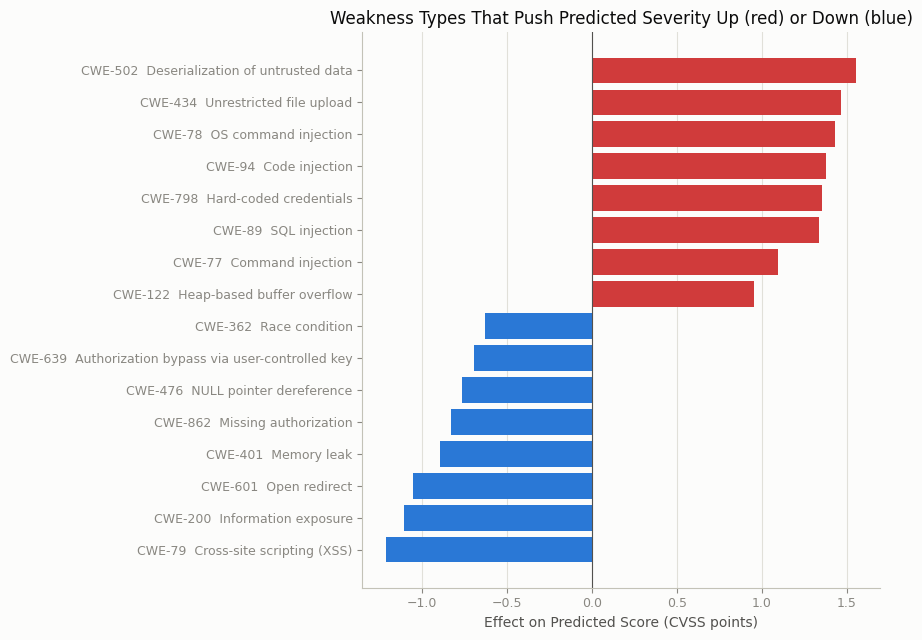

CWE-79    -1.21
CWE-200   -1.11
CWE-601   -1.05
CWE-401   -0.90
CWE-862   -0.83
CWE-476   -0.76
CWE-639   -0.69
CWE-362   -0.62
CWE-122    0.95
CWE-77     1.10
CWE-89     1.34
CWE-798    1.35
CWE-94     1.38
CWE-78     1.43
CWE-434    1.46
CWE-502    1.56

Numeric inputs (CVSS points per standard deviation):
num__published_year          -0.091
num__num_affected_products    0.091


In [20]:
names = best_ridge.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(best_ridge.named_steps["model"].coef_, index=names)

# Weakness-type weights only, for CWEs with at least 1,000 training records.
cwe = coefs[coefs.index.str.startswith("cat__cwe_id_")]
cwe.index = cwe.index.str.replace("cat__cwe_id_", "", regex=False)
cwe_counts = X_train["cwe_id"].value_counts()
cwe = cwe[cwe.index.isin(cwe_counts[cwe_counts >= 1000].index)]
print(f"Common weakness types compared: {len(cwe)}")

# Plain-English names for the weakness types that appear in the chart.
CWE_NAMES = {
    "CWE-502": "Deserialization of untrusted data", "CWE-434": "Unrestricted file upload",
    "CWE-78": "OS command injection", "CWE-94": "Code injection",
    "CWE-798": "Hard-coded credentials", "CWE-89": "SQL injection",
    "CWE-77": "Command injection", "CWE-122": "Heap-based buffer overflow",
    "CWE-79": "Cross-site scripting (XSS)", "CWE-200": "Information exposure",
    "CWE-601": "Open redirect", "CWE-401": "Memory leak",
    "CWE-862": "Missing authorization", "CWE-476": "NULL pointer dereference",
    "CWE-639": "Authorization bypass via user-controlled key", "CWE-362": "Race condition",
}
top = pd.concat([cwe.nlargest(8), cwe.nsmallest(8)]).sort_values()
labels = [f"{c}  {CWE_NAMES.get(c, '')}" for c in top.index]

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(labels, top.values, color=[STATUS["CRITICAL"] if v > 0 else CAT[0] for v in top.values])
ax.axvline(0, color=INK_SECONDARY, linewidth=0.8)
ax.set_title("Weakness Types That Push Predicted Severity Up (red) or Down (blue)")
ax.set_xlabel("Effect on Predicted Score (CVSS points)")
style_ax(ax, y_grid=False, x_grid=True)
ax.tick_params(axis="y", labelsize=9)
fig.savefig("figures/top_drivers.png", dpi=200, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print(top.round(2).to_string())

print("\nNumeric inputs (CVSS points per standard deviation):")
print(coefs[["num__published_year", "num__num_affected_products"]].round(3).to_string())

**Reading this chart:** The pattern matches security intuition. Weaknesses that typically
let an attacker run their own code or take over a system (deserialization, file upload,
command and code injection, SQL injection, hard-coded credentials) push the predicted
score up by about 1.0 to 1.6 points. Weaknesses that usually leak information, redirect a
user, or crash a program (cross-site scripting, information exposure, open redirect,
memory leaks, NULL pointer crashes) push it down by about 0.6 to 1.2 points. The model has
learned real, explainable structure, not noise.

## Step 4: Report

**Summary of results.** Using only descriptive facts about each CVE (vendor, product,
weakness type, publication year, and number of affected products), both regression models
estimated CVSS v3.x severity clearly better than guessing, on 74,017 held-out CVEs neither
model had seen:

| Model | Average error (MAE) | vs. baseline | R-squared |
|---|---|---|---|
| Baseline: always guess the average (7.07) | 1.42 points | n/a | 0.00 |
| Linear regression / tuned Ridge (all 222,049 training rows) | 1.10 points | 23% smaller | 0.31 |
| SVR, RBF kernel, tuned (30,000-row sample) | **1.06 points** | **26% smaller** | 0.31 |

- **SVR was the most accurate on typical cases.** It had the lowest average error even
  though it trained on about one-seventh of the data. Trained on the *same* 30,000 rows,
  linear regression reached only 1.13, so SVR's flexible, curved fit extracts more from
  each record. Linear regression caught up most of the way by using all of the training
  data, which is its practical advantage: it trained in about 2 seconds versus minutes for
  SVR. SVR's RMSE (1.415) was very slightly worse than linear regression's (1.410), meaning
  SVR is closer on typical CVEs but makes slightly larger misses on unusual ones.
- **No meaningful overfitting.** Training and test R-squared were nearly identical for the
  linear models (gap 0.005) and close for SVR (gap 0.04). Regularization tuning chose the
  weakest penalty tested and changed nothing, which confirms there was no overfitting to
  correct: about 727 input columns is small relative to 222,000 training rows.
- **Predictions are pulled toward the middle.** Both models overestimate truly LOW CVEs (by
  about 3.3 points on average) and underestimate truly CRITICAL ones (by about 1.8 points).
  They are most accurate for HIGH CVEs (Ridge MAE 0.78), the largest group.
- **Weakness type is the most interpretable driver.** Code-execution style weaknesses
  (deserialization, file upload, command/code/SQL injection) raise predicted severity;
  information-leak and crash style weaknesses (cross-site scripting, information exposure,
  open redirect, memory leaks) lower it.

**Connection to the hypothesis.** The hypothesis is **supported, with a clear limit.**
Basic published facts do carry real signal about severity: both models beat the baseline
by a wide margin, and they did so honestly, without the score's own ingredients (which,
as section 2.4 showed, would have produced a misleading 0.99 R-squared). But an R-squared
of about 0.31 also means roughly 70% of the variation in severity is *not* explained by
these facts. This project cannot say what accounts for the rest. The technical details recorded
during the full CVSS analysis (how a CVE is reached, what privileges are needed, and what
an attacker gains) are the obvious candidates, since the score is calculated from them,
but that is outside what these models tested.

## Step 5: Act

### 5.1 Turning a predicted score into a triage decision

A security team does not act on "7.3 points"; it acts on "look at this one first". The
check below asks a practical question of the tuned Ridge model on the held-out test CVEs:
**if the team flagged every new CVE with a predicted score of 7.0 or above (HIGH or
CRITICAL) for early review, how well would that work?**

In [21]:
actual_high = y_test >= 7.0          # truly HIGH or CRITICAL
flagged = pred_ridge >= 7.0          # model says "likely HIGH or CRITICAL"

base_rate = actual_high.mean()
precision = actual_high[flagged].mean()        # of flagged CVEs, how many are truly HIGH+
recall = flagged[actual_high].mean()           # of truly HIGH+ CVEs, how many got flagged
critical = y_test >= 9.0
critical_caught = flagged[critical].mean()

print(f"Test CVEs:                                   {len(y_test):,}")
print(f"Truly HIGH or CRITICAL (base rate):          {base_rate:.1%}")
print(f"Flagged by the model (predicted >= 7.0):     {flagged.mean():.1%} of all test CVEs")
print(f"Of flagged CVEs, truly HIGH or CRITICAL:     {precision:.1%}")
print(f"Of truly HIGH/CRITICAL CVEs, flagged:        {recall:.1%}")
print(f"Of truly CRITICAL CVEs, flagged:             {critical_caught:.1%}")

# Ranking view: if the team can only review the top quarter of new CVEs first,
# ordered by predicted score, how many of the truly CRITICAL ones are in that quarter?
top_q = pred_ridge >= np.quantile(pred_ridge, 0.75)
print(f"\nTop 25% by predicted score contains {top_q[critical].mean():.1%} of all CRITICAL CVEs")
print(f"(random picking would contain about 25%).")
print(f"Share of top-25% CVEs that are CRITICAL: {critical[top_q].mean():.1%} "
      f"vs. {critical.mean():.1%} overall")

act = {"base_rate": base_rate, "flagged_share": flagged.mean(), "precision": precision,
       "recall": recall, "critical_caught": critical_caught,
       "topq_critical_capture": top_q[critical].mean(),
       "topq_critical_share": critical[top_q].mean(), "critical_rate": critical.mean()}
pd.Series(act).round(4).to_csv("figures/mp3_act.csv")

Test CVEs:                                   74,017
Truly HIGH or CRITICAL (base rate):          54.7%
Flagged by the model (predicted >= 7.0):     52.5% of all test CVEs
Of flagged CVEs, truly HIGH or CRITICAL:     76.9%
Of truly HIGH/CRITICAL CVEs, flagged:        73.8%
Of truly CRITICAL CVEs, flagged:             86.6%

Top 25% by predicted score contains 59.3% of all CRITICAL CVEs
(random picking would contain about 25%).
Share of top-25% CVEs that are CRITICAL: 33.3% vs. 14.1% overall


**Reading these numbers:** If the team simply reviewed CVEs in random order, about 55% of
what they looked at would be HIGH or CRITICAL. Reviewing the model's flagged list first,
77% would be, and the flagged list still catches 87% of all CRITICAL CVEs. Ranking by
predicted score is even sharper at the top: the top quarter of the queue holds 59% of all
CRITICAL CVEs, more than twice what random ordering would give, and one in three CVEs in
that quarter is CRITICAL (versus one in seven overall).

### 5.2 Applying the model to CVEs that have no score yet

The main cleaned dataset kept 3,256 real CVEs that NVD has not scored yet (section 2.2).
These are exactly the situation this project targets, so the model is applied to them
below to see whether it can produce a useful early-review queue.

In [22]:
# Apply the tuned Ridge model (fast, trained on all training data) to unscored CVEs.
pending = df[~df["has_any_score"]].copy()
for col in CAT_FEATURES:
    pending[col] = pending[col].fillna("Unknown")
pending["predicted_score"] = best_ridge.predict(pending[CAT_FEATURES + NUM_FEATURES]).clip(0, 10)
pending["predicted_band"] = severity_band(pending["predicted_score"])

print(f"Unscored CVEs: {len(pending):,}")
print(f"  ...with no weakness type (CWE) assigned yet: {(pending['cwe_id'] == 'Unknown').mean():.1%}")
print(f"  (compare: scored CVEs in the modeling subset missing CWE: "
      f"{(model_df['cwe_id'] == 'Unknown').mean():.1%})")
print(f"Predicted HIGH or CRITICAL (>= 7.0): {(pending['predicted_score'] >= 7).sum():,} "
      f"({(pending['predicted_score'] >= 7).mean():.1%})")
print("\nPredicted band counts:")
print(pending["predicted_band"].value_counts().reindex(SEVERITY_ORDER).to_string())

print("\nTop 10 unscored CVEs to review first (highest predicted severity):")
queue = pending.sort_values("predicted_score", ascending=False)
print(queue[["cve_id", "primary_vendor", "primary_product", "cwe_id", "predicted_score"]]
      .head(10).round(2).to_string(index=False))
queue[["cve_id", "published_date", "primary_vendor", "primary_product", "cwe_id",
       "predicted_score"]].to_csv("figures/unscored_review_queue.csv", index=False)
pd.Series({"pending": len(pending), "pending_high": int((pending["predicted_score"] >= 7).sum())}) \
    .to_csv("figures/mp3_pending.csv")

Unscored CVEs: 3,256
  ...with no weakness type (CWE) assigned yet: 99.6%
  (compare: scored CVEs in the modeling subset missing CWE: 1.3%)
Predicted HIGH or CRITICAL (>= 7.0): 3,246 (99.7%)

Predicted band counts:
predicted_band
LOW            0
MEDIUM        10
HIGH        3246
CRITICAL       0

Top 10 unscored CVEs to review first (highest predicted severity):
         cve_id                                    primary_vendor     primary_product  cwe_id  predicted_score
  CVE-2023-4674 Yaztek Software Technologies and Computer Systems E-Commerce Software  CWE-89             8.44
CVE-2026-103500                                           Mozilla         Thunderbird Unknown             8.32
 CVE-2024-49203                                           Unknown             Unknown Unknown             8.23
 CVE-2024-54982                                           Unknown             Unknown Unknown             8.10
 CVE-2023-31854                                           Unknown             U

**Reading this result:** This is the most important practical finding of the project. The
model rates almost every unscored CVE as HIGH, in a narrow band, so it does **not**
produce a useful ranking for them. The first lines of output show a clear difference:
nearly all unscored CVEs have **no weakness type (CWE) assigned yet**, while almost every
scored CVE has one. The data shows that these two things go together, not why. Whatever the reason, for these
CVEs the model's most informative input is missing, and it falls back to a generic guess.

The model still works well where it was tested in 5.1: on CVEs whose descriptive fields
are filled in. The lesson is about *when* in a CVE's life the model can help. It cannot
see what has not been recorded yet.

### 5.3 Recommendations

1. **Use the model as a first-pass triage queue, not a replacement for CVSS.** For CVEs
   whose vendor, product, and weakness type are known but whose score is not (for
   example, when the reporting organization supplies a CWE before NVD finishes its
   analysis), sort the review queue by predicted severity so analysts open the most
   likely HIGH and CRITICAL items first. Once the official CVSS score arrives, it replaces
   the estimate.
2. **Do not use it on CVEs with no weakness type.** As 5.2 showed, its predictions there
   collapse to a generic "HIGH" and carry little information. Those CVEs need a different
   signal, such as the written description, which is available from day one.
3. **Prefer linear regression (Ridge) for day-to-day use; keep SVR for comparison.** SVR
   was about 0.04 points more accurate on average, but linear regression trains in seconds
   on all of the data, scores thousands of new CVEs instantly, and its weights can be
   explained to a manager or auditor. For a triage tool, that speed and transparency are
   worth more than a 4% accuracy gain.
4. **Do not trust it at the extremes.** Because predictions are pulled toward the middle,
   a predicted 6.5 can still turn out CRITICAL. Pair the model with simple rules for the
   highest-risk cases, such as always fast-tracking code-execution weakness types
   (CWE-502, CWE-434, CWE-78, CWE-94, CWE-89) regardless of predicted score.
5. **Retrain regularly.** The NVD feed changes every two hours and new vendors, products,
   and weakness types appear constantly. Values the model has never seen fall into a
   generic "infrequent" group, so retraining (seconds for the linear model) keeps it
   current.

### 5.4 Limitations

- The model depends heavily on the weakness type (CWE). Nearly all CVEs still awaiting a
  score have no CWE yet, so the model cannot meaningfully rank them (section 5.2).
- About 70% of the variation in severity is unexplained by these inputs, so individual
  predictions can be off by two or more points.
- Vendor and product are missing for roughly a quarter to a third of records, concentrated
  in older CVEs (shown in Micro-Project 2); these fall back to "Unknown".
- SVR was trained on a 30,000-row sample for practical speed; a full-data SVR might do
  somewhat better.
- The models never read the CVE's written description, which often states the impact
  directly (for example, "allows remote attackers to execute arbitrary code"). That text
  is a natural next source of signal.

### Connection back to the problem statement

The problem statement asked how a security team can decide what to patch first when
CVEs arrive faster every year and official scoring takes time. This project shows that a
simple, fast regression model built from basic descriptive facts can put the most
dangerous vulnerabilities near the front of the line: reviewing its flagged list first
raises the share of HIGH and CRITICAL CVEs from 55% to 77%, and the top quarter of its
ranked queue captures 59% of all CRITICAL CVEs. It is a useful triage aid that saves
analyst time and works alongside the official CVSS score rather than replacing it. Its
clear limit is timing: it needs the weakness type, which brand-new CVEs usually do not
have yet. 